# HCP Task fMRI Analysis: Affect, Reward, and Social Domains

This notebook processes and visualizes Human Connectome Project (HCP) tfMRI data across both cortical surface (`dscalar.nii`) and volumetric (`.nii.gz`) spaces.

By analyzing three specific task contrasts (Emotion, Reward, and Social), the pipeline performs the following operations:
1. **Thresholding & Binarization:** Isolates significant activations (Cohen's d > 0.2).
2. **Winner-Takes-All (WTA) Profiling:** Identifies the most dominant task within shared activation regions.
3. **Overlap Analysis:** Computes and maps the 7 unique combinations of task overlaps.

In [6]:
import logging
import matplotlib.colors as mcolors
from pathlib import Path
import nibabel as nib
from nilearn import plotting
import utils
import numpy as np
import matplotlib.pyplot as plt
import math


plt.rcParams['axes.grid'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
logging.getLogger('nibabel').setLevel(logging.ERROR)

DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOTS_PATH = Path('../plots')
DOCUMENTS_PATH = Path('../documents')
PLOT_KWARGS_DICT = dict(dpi=300, transparent=True, bbox_inches='tight')
INT_MAP_NAME_DICT = {
    1: "Only_Emotion",
    2: "Only_Reward",
    3: "Emotion_and_Reward",
    4: "Only_Social",
    5: "Emotion_and_Social",
    6: "Reward_and_Social",
    7: "All_Three_Tasks"
}

In [7]:
all_surf_img = nib.load(DATA_PATH / 'group/HCP_S1200_997_tfMRI_ALLTASKS_level2_cohensd_hp200_s4_MSMAll.dscalar.nii')
all_surf_data = all_surf_img.get_fdata()
all_vol_img = nib.load(DATA_PATH / 'group/tasks.nii.gz')
all_vol_data = all_vol_img.get_fdata()

# index, show in HCP workbench
task_dict = dict(affect=dict(index=81), reward=dict(index=36), social=dict(index=74), )
task_name_list = list(task_dict.keys())
weight_list = [1, 2, 4]

# Surface Data Processing

In this section, we process the cortical surface data. For each of the three tasks, we extract the task-specific maps from the aggregated CIFTI file and apply a baseline threshold (> 0.2) to define continuous and binary activation masks.

Next, we compute a **Winner-Takes-All (WTA)** map to determine which task exhibits the strongest activation at each vertex. Finally, we calculate an **Overlap Map** using a weighted sum approach to distinctly label all 7 possible combinations of task intersections, saving the resulting maps to the disk.

In [14]:
def make_surf(data, name, template_cifti):
    if data.ndim == 1:
        data = data[np.newaxis, :]
    brain_model_axis = template_cifti.header.get_axis(1)
    scalar_axis = nib.cifti2.ScalarAxis([name])
    new_axes = [scalar_axis, brain_model_axis]
    new_header = nib.cifti2.Cifti2Header.from_axes(new_axes)
    new_cifti_img = nib.Cifti2Image(data, header=new_header)

    return new_cifti_img

In [15]:
# activation
for name, info_dict in task_dict.items():
    surf_data = all_surf_data[info_dict['index'] - 1]
    info_dict['full_surf'] = surf_data
    activation_map = surf_data.copy()
    activation_map[activation_map < 0.2] = 0
    info_dict['activation_surf'] = activation_map
    info_dict['activation_binary_surf'] = (surf_data > 0.2).astype(int)


In [16]:
# winner takes all
stacked_data = np.vstack([task_dict[name]['full_surf'] for name in task_name_list])
wta_indices = np.argmax(stacked_data, axis=0)
max_value_array = np.max(stacked_data, axis=0)
valid_activation_mask = max_value_array > 0.2

for i, name in enumerate(task_name_list):
    winner_mask = (wta_indices == i) & valid_activation_mask
    task_dict[name]['wta_surf'] = winner_mask.astype(float)

In [17]:
# save files
for name, info_dict in task_dict.items():
    for k, v in info_dict.items():
        if k.endswith('_surf'):
            surf_file_path = RESULTS_PATH / f"group/{name}_{k}.dscalar.nii"
            print(f'Saving {surf_file_path.stem}')
            surf_img = make_surf(v, k, all_surf_img)
            nib.save(surf_img, surf_file_path)

Saving affect_full_surf.dscalar
Saving affect_activation_surf.dscalar
Saving affect_activation_binary_surf.dscalar
Saving affect_wta_surf.dscalar
Saving reward_full_surf.dscalar
Saving reward_activation_surf.dscalar
Saving reward_activation_binary_surf.dscalar
Saving reward_wta_surf.dscalar
Saving social_full_surf.dscalar
Saving social_activation_surf.dscalar
Saving social_activation_binary_surf.dscalar
Saving social_wta_surf.dscalar


In [19]:
# overlay
overlap_map = np.zeros_like(task_dict['affect']['activation_binary_surf'])
for i, name in enumerate(task_name_list):
    overlap_map += task_dict[name]['activation_binary_surf'] * weight_list[i]

# calculate all combinations
for val, name_label in INT_MAP_NAME_DICT.items():
    single_combination_mask = (overlap_map == val).astype(float)

    vertex_count = int(np.sum(single_combination_mask))
    surf_img = make_surf(single_combination_mask, name_label, all_surf_img)
    surf_file_path = RESULTS_PATH / f"group/Overlap_{val}_{name_label}.dscalar.nii"
    nib.save(surf_img, surf_file_path)
    print(f'Saved {surf_file_path.stem}')

Saved Overlap_1_Only_Emotion.dscalar
Saved Overlap_2_Only_Reward.dscalar
Saved Overlap_3_Emotion_and_Reward.dscalar
Saved Overlap_4_Only_Social.dscalar
Saved Overlap_5_Emotion_and_Social.dscalar
Saved Overlap_6_Reward_and_Social.dscalar
Saved Overlap_7_All_Three_Tasks.dscalar


# Volume Data Processing

Following the same analytical logic as the surface data, we now process the 3D volumetric data. We generate baseline activation masks, calculate the volumetric Winner-Takes-All (WTA) distribution, and isolate the overlapping voxel combinations.

Each processing step yields individual NIfTI (`.nii.gz`) files, effectively mapping the task-specific and shared functional topographies within the subcortical and whole-brain volumetric space.

In [20]:
# activation
for name, info_dict in task_dict.items():
    vol_data = all_vol_data[..., info_dict['index'] - 1]
    info_dict['full_vol'] = vol_data
    activation_map = vol_data.copy()
    activation_map[activation_map < 0.2] = 0
    info_dict['activation_vol'] = activation_map
    info_dict['activation_binary_vol'] = (vol_data > 0.2).astype(int)

In [21]:
# winner takes all
stacked_data = np.vstack([task_dict[name]['full_vol'] for name in task_name_list])
wta_indices = np.argmax(stacked_data, axis=0)
max_value_array = np.max(stacked_data, axis=0)
valid_activation_mask = max_value_array > 0.2

for i, name in enumerate(task_name_list):
    winner_mask = (wta_indices == i) & valid_activation_mask
    task_dict[name]['wta_vol'] = winner_mask.astype(float)

In [22]:
# save files
for name, info_dict in task_dict.items():
    for k, v in info_dict.items():
        if k.endswith('_vol'):
            vol_file_path = RESULTS_PATH / f"group/{name}_{k}.nii.gz"
            print(f'Saving {vol_file_path.stem}')
            vol_img = nib.Nifti1Image(v, affine=all_vol_img.affine, header=all_vol_img.header)
            nib.save(vol_img, vol_file_path)

Saving affect_full_vol.nii
Saving affect_activation_vol.nii
Saving affect_activation_binary_vol.nii
Saving affect_wta_vol.nii
Saving reward_full_vol.nii
Saving reward_activation_vol.nii
Saving reward_activation_binary_vol.nii
Saving reward_wta_vol.nii
Saving social_full_vol.nii
Saving social_activation_vol.nii
Saving social_activation_binary_vol.nii
Saving social_wta_vol.nii


In [23]:
# Overlap
overlap_map = np.zeros_like(task_dict['affect']['activation_binary_vol'])

for i, name in enumerate(task_name_list):
    overlap_map += task_dict[name]['activation_binary_vol'] * weight_list[i]

for val, name_label in INT_MAP_NAME_DICT.items():
    vol_data = (overlap_map == val).astype(float)
    vol_img = nib.Nifti1Image(vol_data, affine=all_vol_img.affine, header=all_vol_img.header)
    vol_img_file = RESULTS_PATH / f"group/Vol_Overlap_{val}_{name_label}.nii.gz"
    nib.save(vol_img, vol_img_file)
    print(f'Saved {vol_img_file.stem}')


Saved Vol_Overlap_1_Only_Emotion.nii
Saved Vol_Overlap_2_Only_Reward.nii
Saved Vol_Overlap_3_Emotion_and_Reward.nii
Saved Vol_Overlap_4_Only_Social.nii
Saved Vol_Overlap_5_Emotion_and_Social.nii
Saved Vol_Overlap_6_Reward_and_Social.nii
Saved Vol_Overlap_7_All_Three_Tasks.nii


# Visualization Volume Data

This final section generates static 2D slice visualizations of our volumetric results for quality control and reporting.

Using predefined MNI z-axis coordinates and custom Matplotlib colormaps, we visualize:
* **Task Activations:** Both continuous and binary maps for individual tasks.
* **Winner-Takes-All Map:** A discrete 3-color map highlighting the locally dominant functional domain.
* **Overlap Map:** A discrete 7-color map detailing the distinct intersections between the Emotion, Reward, and Social networks.

In [25]:
coord_list = list(range(20, 25, 1))[::-1] + list(range(-24, -19, 1))
cmap_yellows = mcolors.LinearSegmentedColormap.from_list('my_yellows', ['yellow', 'yellow'])

In [29]:
def plot_vol(img, cut_coords, cmap, cols_per_row=5, title=None, is_roi=False, **kwargs):
    """
    General utility function for plotting volumetric NIfTI images.

    Args:
        img (nib.Nifti1Image): NIfTI image object to be plotted.
        cut_coords (list): List of slice coordinates to display.
        cmap (str or Colormap): Colormap to use for the plot.
        cols_per_row (int, optional): Number of slices displayed per row. Defaults to 5.
        title (str, optional): Main title for the overall figure. Defaults to None.
        is_roi (bool, optional): If True, plots as a discrete categorical map using `plot_roi`
                                 (e.g., for WTA maps). If False, plots as a continuous statistical
                                 map using `plot_stat_map`. Defaults to False.
        **kwargs: Additional keyword arguments passed to the underlying nilearn.plotting
                  functions (e.g., threshold, vmin, vmax, display_mode).

    Returns:
        tuple: (fig, axes) Matplotlib figure and axes objects.
    """
    n_slices = len(cut_coords)
    n_rows = math.ceil(n_slices / cols_per_row)

    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(cols_per_row * 3, n_rows * 3))

    if n_rows * cols_per_row == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    plot_params = {
        'display_mode': 'x',
        'draw_cross': False,
        'annotate': True,
        'colorbar': False,
        'cmap': cmap
    }
    plot_params.update(kwargs)

    for i, coord in enumerate(cut_coords):
        plot_params['cut_coords'] = [coord]
        plot_params['axes'] = axes[i]

        if is_roi:
            plotting.plot_roi(img, **plot_params)
        else:
            plotting.plot_stat_map(img, **plot_params)

    for j in range(n_slices, len(axes)):
        axes[j].axis('off')

    if title:
        fig.suptitle(title, fontsize=16, y=1.02)

    return fig, axes

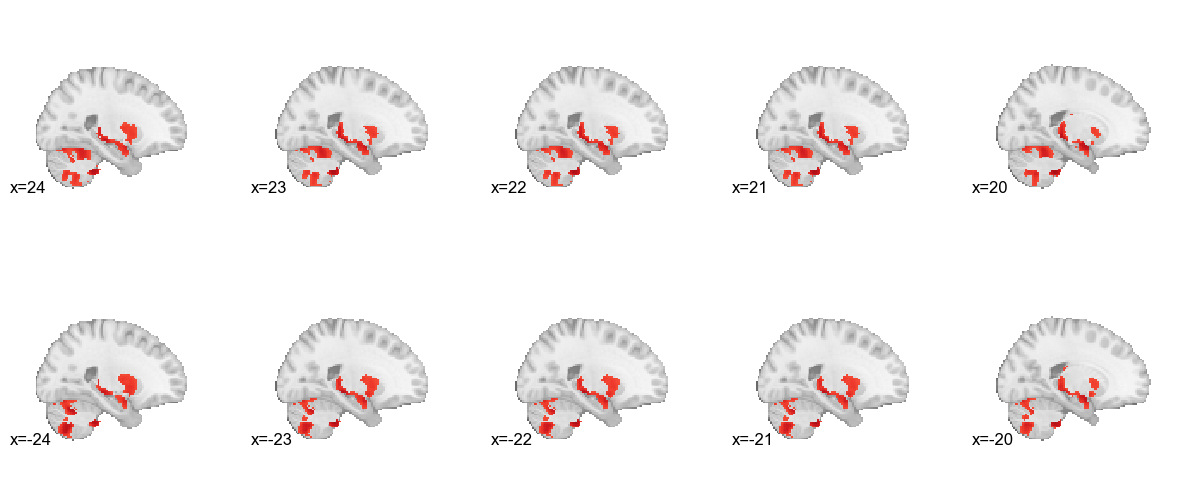

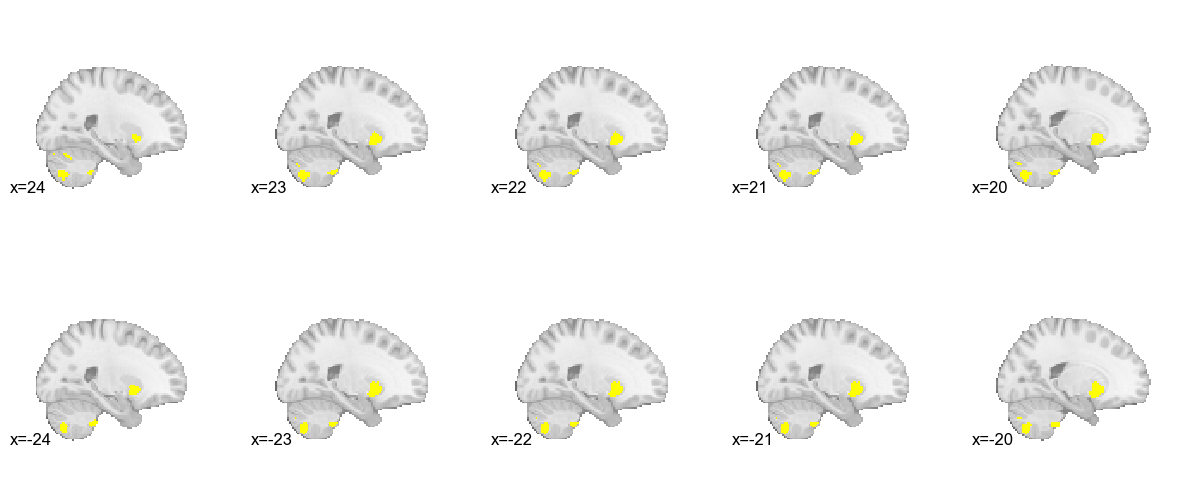

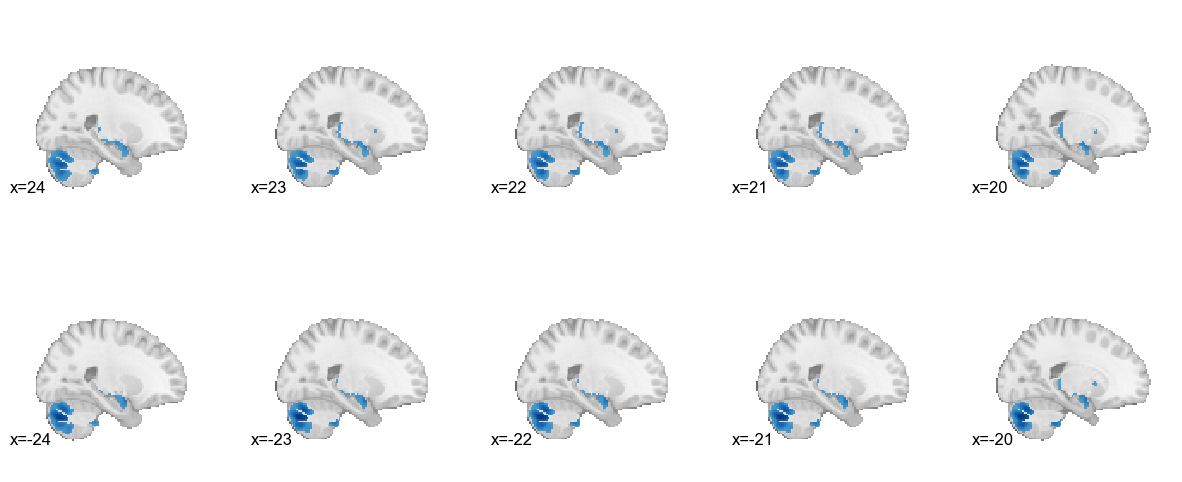

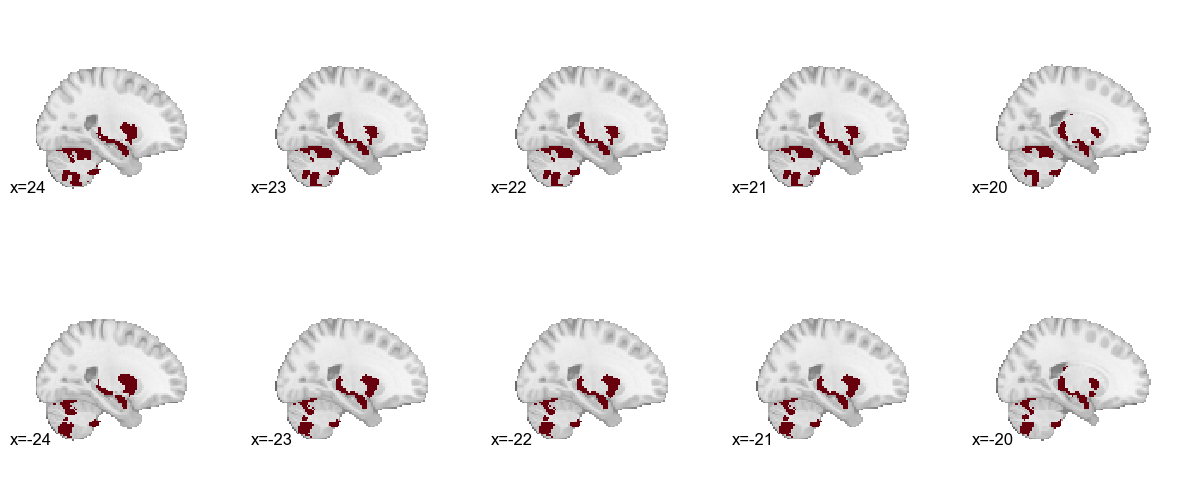

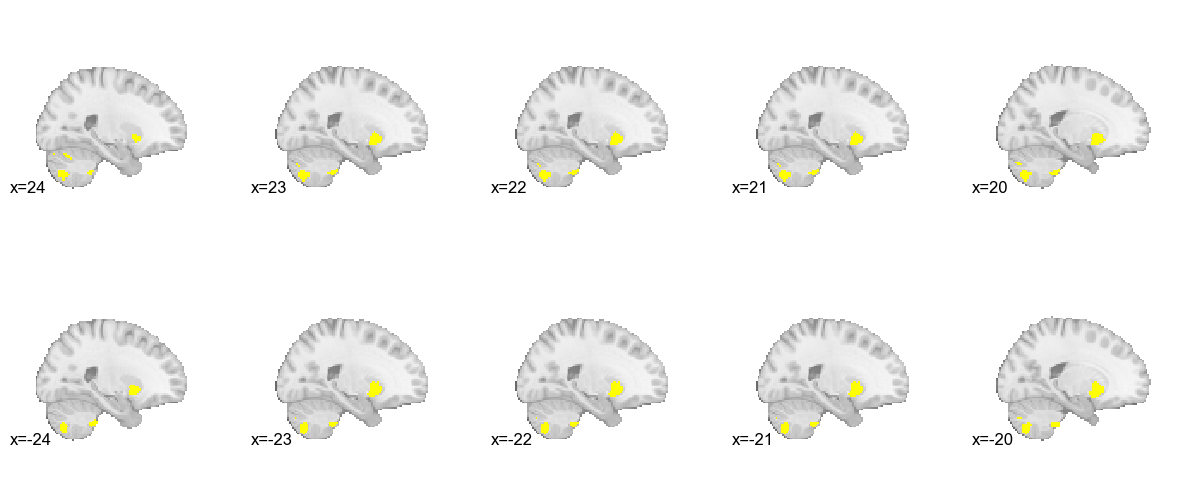

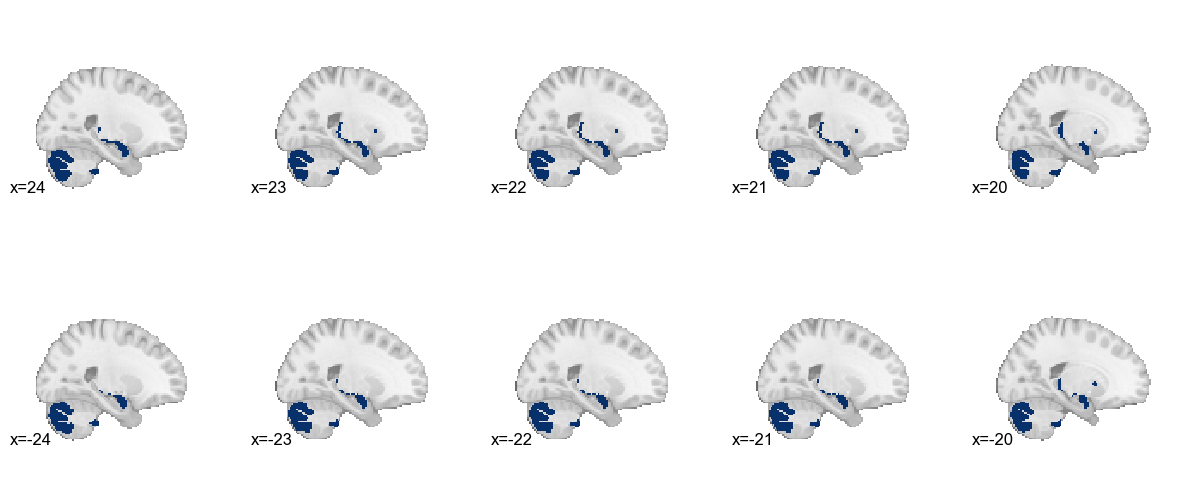

In [30]:
cmap_list = ['Reds', cmap_yellows, 'Blues']

for idx, (name, info_dict) in enumerate(task_dict.items()):
    vol_data = info_dict['activation_vol']
    vol_img = nib.Nifti1Image(vol_data, affine=all_vol_img.affine, header=all_vol_img.header)
    current_cmap = cmap_list[idx % len(cmap_list)]
    fig, axes = plot_vol(img=vol_img, cut_coords=coord_list, cmap=current_cmap, )
    fig.savefig(PLOTS_PATH / f"group/{name}_activation_vol.png", **PLOT_KWARGS_DICT)

for idx, (name, info_dict) in enumerate(task_dict.items()):
    vol_data = info_dict['activation_binary_vol']
    vol_img = nib.Nifti1Image(vol_data, affine=all_vol_img.affine, header=all_vol_img.header)

    current_cmap = cmap_list[idx % len(cmap_list)]
    fig, axes = plot_vol(img=vol_img, cut_coords=coord_list, cmap=current_cmap, )
    fig.savefig(PLOTS_PATH / f"group/{name}_activation_binary_vol.png", **PLOT_KWARGS_DICT)

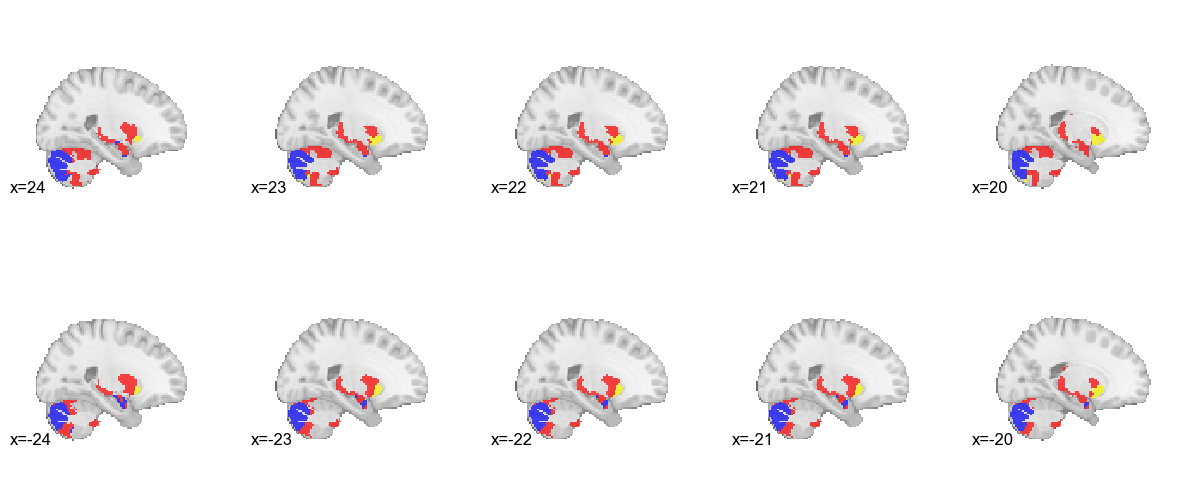

In [31]:
# winner takes all
stacked_data = np.array([task_dict[name]['full_vol'] for name in task_name_list])

wta_indices = np.argmax(stacked_data, axis=0)
max_value_array = np.max(stacked_data, axis=0)
valid_activation_mask = max_value_array > 0.2

wta_map = np.zeros_like(max_value_array)
for i, name in enumerate(task_name_list):
    winner_mask = (wta_indices == i) & valid_activation_mask
    task_dict[name]['wta_nii'] = winner_mask.astype(float)
    wta_map[winner_mask] = i + 1

wta_img = nib.Nifti1Image(wta_map, affine=all_vol_img.affine, header=all_vol_img.header)
coords_wta = list(range(20, 25, 1))
cmap_wta = mcolors.ListedColormap(['red', 'yellow', 'blue'])
wta_plot_path = PLOTS_PATH / "group/WTA_vol.png"
fig, axes = plot_vol(
    img=wta_img, cut_coords=coord_list, cmap=cmap_wta,
    cols_per_row=5, is_roi=True, vmin=1, vmax=3)

fig.savefig(wta_plot_path, **PLOT_KWARGS_DICT)

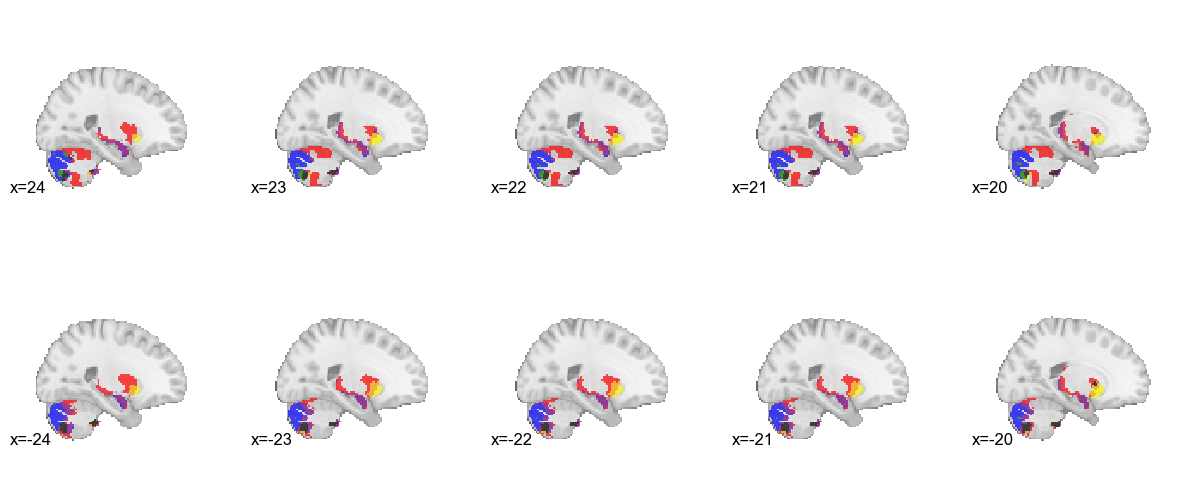

In [32]:
# overlap
overlap_map = np.zeros_like(task_dict[task_name_list[0]]['activation_binary_vol'])
for i, name in enumerate(task_name_list):
    overlap_map += task_dict[name]['activation_binary_vol'] * weight_list[i]
overlap_img = nib.Nifti1Image(overlap_map, affine=all_vol_img.affine, header=all_vol_img.header)
out_path = RESULTS_PATH / "Vol_Overlap_7_Combinations.nii.gz"
nib.save(overlap_img, out_path)

colors_7 = ['red', 'yellow', 'orange', 'blue', 'purple', 'green', 'black']
cmap_overlap = mcolors.ListedColormap(colors_7)
coords_overlap = list(range(20, 25, 1))
fig, axes = plot_vol(
    img=overlap_img,    cut_coords=coord_list,    cmap=cmap_overlap,    cols_per_row=5,
    is_roi=True,    vmin=1,    vmax=7,)
fig.savefig(PLOTS_PATH / "group/Overlap_vol.png", **PLOT_KWARGS_DICT)
